In [21]:
import cv2
import numpy as np
import os
import math
from glob import glob

In [65]:
import cv2
import numpy as np
import math
import os # Added for path joining

def calculate_rotation_angle(image_path1, image_path2, max_features=500, good_match_percent=0.15):
    """
    Calculates the rotation angle between two images.

    Args:
        image_path1 (str): Path to the first image.
        image_path2 (str): Path to the second image.
        max_features (int): Maximum number of features to detect.
        good_match_percent (float): Percentage of top matches to keep.

    Returns:
        float: The calculated rotation angle in degrees, or None if an error occurs.
    """
    try:
        # Load images
        img1_color = cv2.imread(image_path1)
        img2_color = cv2.imread(image_path2)

        if img1_color is None:
            print(f"Error: Could not load image 1 from {image_path1}")
            return None
        if img2_color is None:
            print(f"Error: Could not load image 2 from {image_path2}")
            return None

        # Convert images to grayscale
        img1 = cv2.cvtColor(img1_color, cv2.COLOR_BGR2GRAY)
        img2 = cv2.cvtColor(img2_color, cv2.COLOR_BGR2GRAY)

        # 1. Detect ORB features and compute descriptors.
        # ORB (Oriented FAST and Rotated BRIEF) is a good choice.
        orb = cv2.ORB_create(nfeatures=max_features)
        keypoints1, descriptors1 = orb.detectAndCompute(img1, None)
        keypoints2, descriptors2 = orb.detectAndCompute(img2, None)

        if descriptors1 is None or descriptors2 is None:
            print("Error: Could not compute descriptors. Not enough features found in one or both images.")
            return None
        
        if len(descriptors1) == 0 or len(descriptors2) == 0:
            print("Error: No descriptors found in one or both images.")
            return None

        # 2. Match features.
        # BFMatcher (Brute-Force Matcher).
        # NORM_HAMMING is used for ORB descriptors.
        # crossCheck=True returns only those pairs (i,j) such that descriptor_i is the best match for descriptor_j and vice-versa.
        matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
        matches = matcher.match(descriptors1, descriptors2) # This should return a list of DMatch objects

        # Sort matches by score (distance). Lower distance is better.
        # Using sorted() function which returns a new list and works on any iterable.
        matches = sorted(matches, key=lambda x: x.distance, reverse=False)

        # Remove not so good matches
        num_good_matches = int(len(matches) * good_match_percent)
        good_matches = matches[:num_good_matches]

        if len(good_matches) < 4: # Need at least 4 points for findHomography, or 2 for estimateAffinePartial2D (though more is better)
            print(f"Error: Not enough good matches found ({len(good_matches)} out of {len(matches)} total matches). "
                  f"Try adjusting good_match_percent (current: {good_match_percent}) "
                  f"or max_features (current: {max_features}).")
            if len(matches) > 0 :
                 print(f"Distance of best match: {matches[0].distance}, distance of worst 'good' match (if any): {good_matches[-1].distance if good_matches else 'N/A'}")
            return None

        # Print number of good matches
        print(f"Found {len(keypoints1)} keypoints in image 1.")
        print(f"Found {len(keypoints2)} keypoints in image 2.")
        print(f"Found {len(matches)} total matches after cross-check.")
        print(f"Keeping {len(good_matches)} good matches (top {good_match_percent*100}%).")


        # Optional: Draw top matches for visualization
        # img_matches = cv2.drawMatches(img1_color, keypoints1, img2_color, keypoints2, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
        # cv2.imshow("Good Matches", img_matches)
        # cv2.waitKey(0)
        # cv2.destroyAllWindows() # Make sure to destroy window if you display it


        # 3. Extract location of good matches
        points1 = np.zeros((len(good_matches), 2), dtype=np.float32)
        points2 = np.zeros((len(good_matches), 2), dtype=np.float32)

        for i, match_item in enumerate(good_matches): # Renamed 'match' to 'match_item' to avoid conflict with module name
            points1[i, :] = keypoints1[match_item.queryIdx].pt
            points2[i, :] = keypoints2[match_item.trainIdx].pt

        # 4. Estimate Affine Transformation
        # M is the 2x3 transformation matrix.
        # We use estimateAffinePartial2D for rotation, scale, and translation.
        # It's generally robust for this kind of problem.
        M, inliers = cv2.estimateAffinePartial2D(points1, points2, method=cv2.RANSAC, ransacReprojThreshold=5.0)

        print(M)
        
        if M is None:
            print("Error: Could not estimate affine transformation. "
                  "This can happen if matches are poor or inconsistent, or if there's no clear affine relationship. "
                  "Check match quality or image content. Consider if RANSAC threshold is appropriate.")
            return None
        
        print(f"Number of inliers selected by RANSAC: {np.sum(inliers)} out of {len(good_matches)} provided points.")
        if np.sum(inliers) < 4 : # Technically 3 non-collinear points for affine, but more is robust
            print("Warning: Very few inliers found by RANSAC. The estimated transform might be unreliable.")


        # 5. Extract rotation angle from the matrix
        # M = [[s*cos(theta), -s*sin(theta), tx],
        #      [s*sin(theta),  s*cos(theta), ty]]
        # angle = atan2(sin_component, cos_component)
        
        # M[1,0] is s*sin(theta)
        # M[0,0] is s*cos(theta)
        angle_rad = math.atan2(M[1, 0], M[0, 0])
        angle_deg = math.degrees(angle_rad)

        # You can also extract scale if interested:
        # scale = np.sqrt(M[0,0]**2 + M[1,0]**2) # or M[0,1]**2 + M[1,1]**2
        # print(f"Estimated Scale: {scale:.3f}")
        # print(f"Translation (tx, ty): ({M[0,2]:.2f}, {M[1,2]:.2f})")

        return angle_deg

    except Exception as e:
        print(f"An unexpected error occurred in calculate_rotation_angle: {e}")
        import traceback
        traceback.print_exc()
        return None


In [66]:
# Or provide full paths directly:
image_path_1 = "/Users/mateo/pyronear/vision/smoke-localization/nemours_12_session_20250523_095927/im_12_00.jpg" # Replace with your first image file
image_path_2 = "/Users/mateo/pyronear/vision/smoke-localization/nemours_12_session_20250523_095927/im_12_01.jpg" # Replace with your second image file
# --- ---

print(f"Processing image 1: {image_path_1}")
print(f"Processing image 2: {image_path_2}")

if not os.path.exists(image_path_1):
    print(f"FATAL ERROR: Image file not found at {image_path_1}")
elif not os.path.exists(image_path_2):
    print(f"FATAL ERROR: Image file not found at {image_path_2}")
else:
    rotation_angle = calculate_rotation_angle(image_path_1, image_path_2, max_features=1000, good_match_percent=0.2)

    if rotation_angle is not None:
        print(f"\n----------------------------------------------------")
        print(f"Estimated rotation angle: {rotation_angle:.3f} degrees")
        print(f"----------------------------------------------------")

Processing image 1: /Users/mateo/pyronear/vision/smoke-localization/nemours_12_session_20250523_095927/im_12_00.jpg
Processing image 2: /Users/mateo/pyronear/vision/smoke-localization/nemours_12_session_20250523_095927/im_12_01.jpg
Found 1000 keypoints in image 1.
Found 1000 keypoints in image 2.
Found 438 total matches after cross-check.
Keeping 87 good matches (top 20.0%).
[[ 1.01719361e+00  8.86997619e-03 -9.01546420e+02]
 [-8.86997619e-03  1.01719361e+00  1.73229827e+00]]
Number of inliers selected by RANSAC: 62 out of 87 provided points.

----------------------------------------------------
Estimated rotation angle: -0.500 degrees
----------------------------------------------------


In [67]:
image_path_2

'/Users/mateo/pyronear/vision/smoke-localization/nemours_12_session_20250523_095927/im_12_01.jpg'

In [ ]:
import cv2
import numpy as np
import math
import os

def calculate_rotation_angle(image_path1, image_path2, max_features=500, good_match_percent=0.15, ransac_thresh=5.0, show_matches=True):
    """
    Calculates the rotation angle between two images.

    Args:
        image_path1 (str): Path to the first image.
        image_path2 (str): Path to the second image.
        max_features (int): Maximum number of features to detect.
        good_match_percent (float): Percentage of top matches to keep.
        ransac_thresh (float): RANSAC reprojection threshold for estimateAffinePartial2D.
        show_matches (bool): Whether to display the good matches.

    Returns:
        float: The calculated rotation angle in degrees, or None if an error occurs.
    """
    try:
        img1_color = cv2.imread(image_path1)
        img2_color = cv2.imread(image_path2)

        if img1_color is None:
            print(f"Error: Could not load image 1 from {image_path1}")
            return None
        if img2_color is None:
            print(f"Error: Could not load image 2 from {image_path2}")
            return None

        img1 = cv2.cvtColor(img1_color, cv2.COLOR_BGR2GRAY)
        img2 = cv2.cvtColor(img2_color, cv2.COLOR_BGR2GRAY)

        orb = cv2.ORB_create(nfeatures=max_features)
        keypoints1, descriptors1 = orb.detectAndCompute(img1, None)
        keypoints2, descriptors2 = orb.detectAndCompute(img2, None)

        if descriptors1 is None or descriptors2 is None or len(descriptors1) == 0 or len(descriptors2) == 0:
            print("Error: Could not compute descriptors or no descriptors found.")
            return None

        matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
        matches = matcher.match(descriptors1, descriptors2)
        matches = sorted(matches, key=lambda x: x.distance, reverse=False)

        num_good_matches = int(len(matches) * good_match_percent)
        good_matches = matches[:num_good_matches]

        print(f"Found {len(keypoints1)} keypoints in image 1.")
        print(f"Found {len(keypoints2)} keypoints in image 2.")
        print(f"Found {len(matches)} total matches after cross-check.")
        
        if len(good_matches) < 4:
            print(f"Error: Not enough good matches found ({len(good_matches)}). Need at least 4. "
                  f"Total matches: {len(matches)}. Try adjusting good_match_percent (current: {good_match_percent}) "
                  f"or max_features (current: {max_features}).")
            return None
        
        print(f"Keeping {len(good_matches)} good matches (top {good_match_percent*100:.1f}%).")

        if show_matches:
            # Draw good matches
            img_matches = cv2.drawMatches(img1_color, keypoints1, img2_color, keypoints2, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
            
            # Resize for display if too large
            h, w = img_matches.shape[:2]
            max_display_width = 1600 # Adjust as needed
            max_display_height = 900 # Adjust as needed
            if w > max_display_width or h > max_display_height:
                scale = min(max_display_width / w, max_display_height / h)
                img_matches_display = cv2.resize(img_matches, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
            else:
                img_matches_display = img_matches

            cv2.imshow("Good Matches (Press any key to continue)", img_matches_display)
            print("Visualizing good matches. Press any key in the 'Good Matches' window to continue...")
            cv2.waitKey(0)
            cv2.destroyAllWindows()


        points1 = np.zeros((len(good_matches), 2), dtype=np.float32)
        points2 = np.zeros((len(good_matches), 2), dtype=np.float32)

        for i, match_item in enumerate(good_matches):
            points1[i, :] = keypoints1[match_item.queryIdx].pt
            points2[i, :] = keypoints2[match_item.trainIdx].pt

        M, inliers = cv2.estimateAffinePartial2D(points1, points2, method=cv2.RANSAC, ransacReprojThreshold=ransac_thresh)
        
        if M is None:
            print(f"Error: Could not estimate affine transformation with RANSAC threshold {ransac_thresh}. "
                  "Check match quality or image content. Not enough inliers found.")
            return None
        
        num_inliers = np.sum(inliers)
        print(f"Number of inliers selected by RANSAC: {num_inliers} out of {len(good_matches)} provided points (using threshold {ransac_thresh}).")
        
        if num_inliers < 3: # Need at least 3 non-collinear points for affine
            print("Warning: Very few inliers found by RANSAC (<3). The estimated transform is likely unreliable.")
            return None

        angle_rad = math.atan2(M[1, 0], M[0, 0])
        angle_deg = math.degrees(angle_rad)
        
        scale = np.sqrt(M[0,0]**2 + M[1,0]**2)
        print(f"Estimated Scale: {scale:.3f}")
        print(f"Transformation Matrix M:\n{M}")


        return angle_deg

    except Exception as e:
        print(f"An unexpected error occurred in calculate_rotation_angle: {e}")
        import traceback
        traceback.print_exc()
        return None

if __name__ == '__main__':
    image_path_1 = "/Users/mateo/pyronear/vision/smoke-localization/nemours_12_session_20250523_095927/im_12_00.jpg"
    image_path_2 = "/Users/mateo/pyronear/vision/smoke-localization/nemours_12_session_20250523_095927/im_12_01.jpg"

    print(f"Processing image 1: {image_path_1}")
    print(f"Processing image 2: {image_path_2}")

    if not os.path.exists(image_path_1):
        print(f"FATAL ERROR: Image file not found at {image_path_1}")
    elif not os.path.exists(image_path_2):
        print(f"FATAL ERROR: Image file not found at {image_path_2}")
    else:
        # --- Experiment with these parameters ---
        # Initial parameters that gave -0.5 deg:
        # current_max_features = 1000
        # current_good_match_percent = 0.20
        # current_ransac_thresh = 5.0 
        # show_the_matches = True

        # Try more features, more selective matches, stricter RANSAC
        current_max_features = 2000       # Increased from 1000
        current_good_match_percent = 0.10 # More selective, top 10% instead of 20%
        current_ransac_thresh = 3.0       # Stricter RANSAC threshold (was 5.0)
        show_the_matches = True           # KEEP THIS TRUE FOR DIAGNOSIS

        # Alternative: if the above is too strict and finds no matches/inliers
        # current_max_features = 1500
        # current_good_match_percent = 0.25 # Less selective if previous was too strict
        # current_ransac_thresh = 5.0
        # show_the_matches = True
        
        print(f"\nAttempting with: max_features={current_max_features}, good_match_percent={current_good_match_percent}, ransac_thresh={current_ransac_thresh}")

        rotation_angle = calculate_rotation_angle(
            image_path_1, 
            image_path_2, 
            max_features=current_max_features, 
            good_match_percent=current_good_match_percent,
            ransac_thresh=current_ransac_thresh,
            show_matches=show_the_matches
        )

        if rotation_angle is not None:
            print(f"\n----------------------------------------------------")
            print(f"Estimated rotation angle: {rotation_angle:.3f} degrees")
            print(f"----------------------------------------------------")
        else:
            print("\nCould not calculate the rotation angle with current parameters.")
            print("Tips: Examine the 'Good Matches' window carefully. ")
            print("Are matches on the correct (rotated) parts of the image?")
            print("Adjust 'max_features', 'good_match_percent', and 'ransac_thresh'.")



Processing image 1: /Users/mateo/pyronear/vision/smoke-localization/nemours_12_session_20250523_095927/im_12_00.jpg
Processing image 2: /Users/mateo/pyronear/vision/smoke-localization/nemours_12_session_20250523_095927/im_12_01.jpg

Attempting with: max_features=2000, good_match_percent=0.1, ransac_thresh=3.0
Found 2000 keypoints in image 1.
Found 2000 keypoints in image 2.
Found 865 total matches after cross-check.
Keeping 86 good matches (top 10.0%).
Visualizing good matches. Press any key in the 'Good Matches' window to continue...


[INFO] Nombre de keypoints dans image 1 : 1000
[INFO] Nombre de keypoints dans image 2 : 1000
[INFO] Nombre de bons appariements conservés : 100
[INFO] Matrice affine estimée :
[[ 1.01516905e+00  7.71789933e-03 -8.95182344e+02]
 [-7.71789933e-03  1.01516905e+00  2.83430283e+00]]
[INFO] Nombre d'inliers RANSAC : 58 / 100
[RESULTAT] Angle de rotation estimé : -0.44°


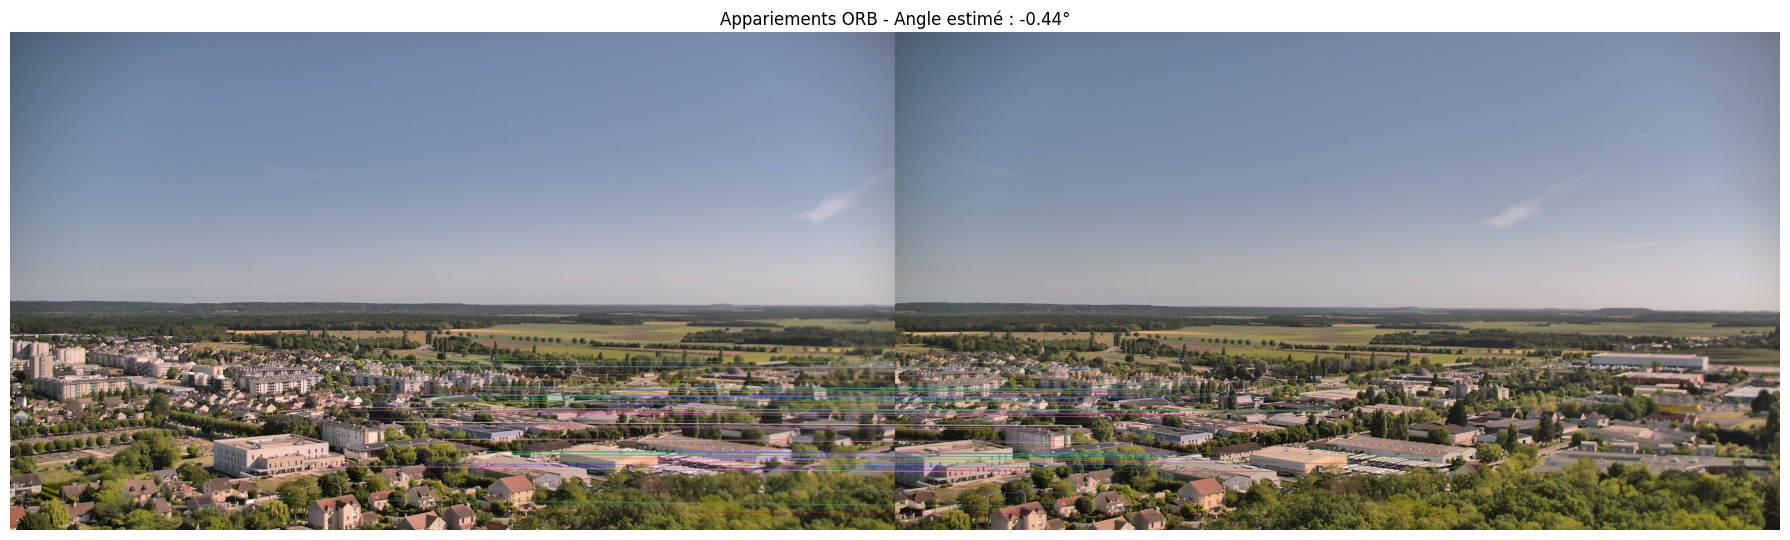

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

# === 1. Chemins des images ===
image_path_1 = "/Users/mateo/pyronear/vision/smoke-localization/nemours_12_session_20250523_095927/im_12_00.jpg"
image_path_2 = "/Users/mateo/pyronear/vision/smoke-localization/nemours_12_session_20250523_095927/im_12_01.jpg"

# === 2. Chargement des images ===
img1_color = cv2.imread(image_path_1)
img2_color = cv2.imread(image_path_2)

if img1_color is None or img2_color is None:
    raise ValueError("Erreur de chargement des images")

img1_gray = cv2.cvtColor(img1_color, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2_color, cv2.COLOR_BGR2GRAY)

# === 3. Détection des points clés ORB ===
orb = cv2.ORB_create(nfeatures=1000)
kp1, des1 = orb.detectAndCompute(img1_gray, None)
kp2, des2 = orb.detectAndCompute(img2_gray, None)

print(f"[INFO] Nombre de keypoints dans image 1 : {len(kp1)}")
print(f"[INFO] Nombre de keypoints dans image 2 : {len(kp2)}")

# === 4. Appariement avec BFMatcher et cross-check ===
matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = matcher.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

# === 5. Garde les meilleurs appariements ===
good_matches = matches[:100]  # top 100
print(f"[INFO] Nombre de bons appariements conservés : {len(good_matches)}")

# === 6. Extraction des points appariés ===
pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches])
pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches])

# === 7. Estimation de la transformation affine partielle ===
M, inliers = cv2.estimateAffinePartial2D(pts1, pts2, method=cv2.RANSAC)

if M is None:
    raise RuntimeError("Impossible d’estimer la transformation affine")

print("[INFO] Matrice affine estimée :")
print(M)
print(f"[INFO] Nombre d'inliers RANSAC : {np.sum(inliers)} / {len(good_matches)}")

# === 8. Calcul de l’angle de rotation ===
angle_rad = math.atan2(M[1, 0], M[0, 0])
angle_deg = math.degrees(angle_rad)
print(f"[RESULTAT] Angle de rotation estimé : {angle_deg:.2f}°")

# === 9. Affichage des appariements ===
img_matches = cv2.drawMatches(img1_color, kp1, img2_color, kp2, good_matches, None,
                              flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(18, 10))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title(f"Appariements ORB - Angle estimé : {angle_deg:.2f}°")
plt.axis('off')
plt.tight_layout()
plt.show()


[INFO] Keypoints détectés : 1000 / 1000
[INFO] Δx moyen (filtré) : 45.85 px
[RESULTAT] Angle de rotation estimé : 0.70° avec 7 points


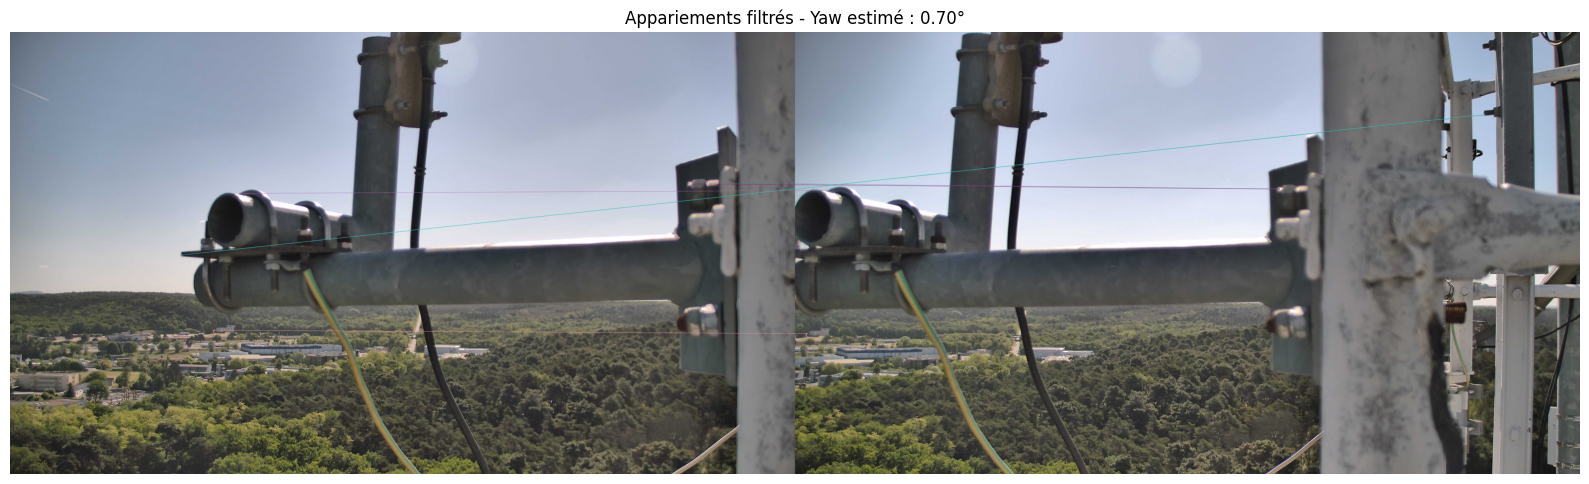

0.70011493444385

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def estimate_yaw_from_dx(img_path1, img_path2, fov_deg=54.2, match_count=100):
    # Chargement
    img1 = cv2.imread(img_path1)
    img2 = cv2.imread(img_path2)
    img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    H, W = img1.shape[:2]

    # Détection ORB
    orb = cv2.ORB_create(nfeatures=1000)
    kp1, des1 = orb.detectAndCompute(img1_gray, None)
    kp2, des2 = orb.detectAndCompute(img2_gray, None)

    print(f"[INFO] Keypoints détectés : {len(kp1)} / {len(kp2)}")

    # Appariement
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)[:match_count]

    # Filtrage spatial : on garde seulement les points bien distribués latéralement
    margin_x = W * 0.2  # ignorer les points trop proches du centre
    margin_y = H * 0.1  # ignorer les zones haut/bas

    dx_list = []
    good_matches = []

    for m in matches:
        x1, y1 = kp1[m.queryIdx].pt
        x2, y2 = kp2[m.trainIdx].pt

        if abs(x1 - W/2) > margin_x and margin_y < y1 < H - margin_y and margin_y < y2 < H - margin_y:
            dx_list.append(x2 - x1)
            good_matches.append(m)

    if not dx_list:
        print("Aucun match utile pour l’estimation.")
        return None

    mean_dx = np.mean(dx_list)

    # Calcul de l’angle à partir de dx
    fov_rad = np.radians(fov_deg)
    angle_rad = 2 * np.arctan((mean_dx * np.tan(fov_rad / 2)) / W)
    angle_deg = np.degrees(angle_rad)

    print(f"[INFO] Δx moyen (filtré) : {mean_dx:.2f} px")
    print(f"[RESULTAT] Angle de rotation estimé : {angle_deg:.2f}° avec {len(good_matches)} points")

    # Affichage des appariements filtrés
    match_img = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, None, flags=2)
    plt.figure(figsize=(16, 8))
    plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Appariements filtrés - Yaw estimé : {angle_deg:.2f}°")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return angle_deg

# === Exécution
img1_path = "/Users/mateo/pyronear/vision/smoke-localization/nemours_12_session_20250523_095927/im_12_06.jpg"
img2_path = "/Users/mateo/pyronear/vision/smoke-localization/nemours_12_session_20250523_095927/im_12_07.jpg"

estimate_yaw_from_dx(img1_path, img2_path)


In [7]:
360/13

27.692307692307693

  6%|▌         | 2/35 [00:00<00:04,  7.07it/s]

im_12_00.jpg → im_12_01.jpg : -13.07°
im_12_01.jpg → im_12_02.jpg : -13.32°


 11%|█▏        | 4/35 [00:00<00:04,  7.74it/s]

im_12_02.jpg → im_12_03.jpg : -13.45°
im_12_03.jpg → im_12_04.jpg : -13.99°


 17%|█▋        | 6/35 [00:00<00:03,  8.18it/s]

...

im_12_29.jpg → im_12_30.jpg : -13.76°
im_12_30.jpg → im_12_31.jpg : -13.40°


 94%|█████████▍| 33/35 [00:04<00:00,  7.22it/s]

im_12_31.jpg → im_12_32.jpg : -13.09°
im_12_32.jpg → im_12_33.jpg : -12.98°


100%|██████████| 35/35 [00:04<00:00,  7.72it/s]

im_12_33.jpg → im_12_34.jpg : -13.49°
im_12_34.jpg → im_12_35.jpg : -13.24°

=== Azimuts cumulés ===
           image  azimut_estime
0   im_12_00.jpg       0.000000
1   im_12_01.jpg     -13.066223
2   im_12_02.jpg     -26.383532
3   im_12_03.jpg     -39.835979
4   im_12_04.jpg     -53.827574
5   im_12_05.jpg     -67.549660
6   im_12_06.jpg     -80.796038
7   im_12_07.jpg     -80.095923
8   im_12_08.jpg     -93.502635
9   im_12_09.jpg    -106.427315
10  im_12_10.jpg    -106.427315
11  im_12_11.jpg     -67.521410
12  im_12_12.jpg     -81.068367
13  im_12_13.jpg     -94.270918
14  im_12_14.jpg    -107.727680
15  im_12_15.jpg    -121.511921
16  im_12_16.jpg    -134.643046
17  im_12_17.jpg    -148.579370
18  im_12_18.jpg    -162.105733
19  im_12_19.jpg    -176.292578
20  im_12_20.jpg    -189.344832
21  im_12_21.jpg    -202.399672
22  im_12_22.jpg    -216.397533
23  im_12_23.jpg    -229.458872
24  im_12_24.jpg    -242.294019
25  im_12_25.jpg    -255.315595
26  im_12_26.jpg    -268.348078
27 

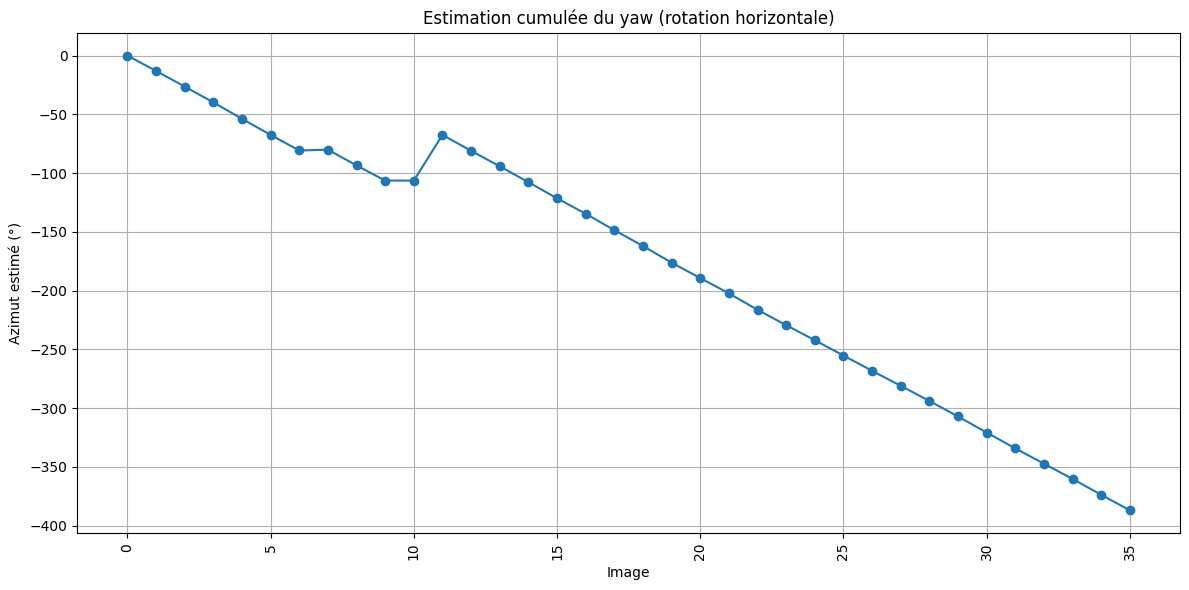

In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
import pandas as pd

def estimate_dx_angle(img1, img2, fov_deg=54.2, match_count=100):
    img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    H, W = img1.shape[:2]

    orb = cv2.ORB_create(nfeatures=1000)
    kp1, des1 = orb.detectAndCompute(img1_gray, None)
    kp2, des2 = orb.detectAndCompute(img2_gray, None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)[:match_count]

    margin_x = W * 0.2
    margin_y = H * 0.1

    dx_list = []
    for m in matches:
        x1, y1 = kp1[m.queryIdx].pt
        x2, y2 = kp2[m.trainIdx].pt
        if abs(x1 - W / 2) > margin_x and margin_y < y1 < H - margin_y and margin_y < y2 < H - margin_y:
            dx_list.append(x2 - x1)

    if not dx_list:
        return None

    mean_dx = np.mean(dx_list)
    fov_rad = np.radians(fov_deg)
    angle_rad = 2 * np.arctan((mean_dx * np.tan(fov_rad / 2)) / W)
    return np.degrees(angle_rad)

def process_folder_yaw(folder_path, fov_deg=54.2):
    image_paths = sorted(glob(os.path.join(folder_path, "*.jpg")))
    if len(image_paths) < 2:
        raise ValueError("Le dossier doit contenir au moins deux images")

    angles = []
    cumulative_angles = [0]

    for i in tqdm(range(len(image_paths) - 1)):
        img1 = cv2.imread(image_paths[i])
        img2 = cv2.imread(image_paths[i + 1])

        angle = estimate_dx_angle(img1, img2, fov_deg=fov_deg)

        if angle is None:
            print(f"[WARNING] Angle non estimé entre {os.path.basename(image_paths[i])} et {os.path.basename(image_paths[i+1])}")
            angle = 0  # Ou None si tu veux l'ignorer

        angles.append(angle)
        cumulative_angles.append(cumulative_angles[-1] + angle)

        print(f"{os.path.basename(image_paths[i])} → {os.path.basename(image_paths[i+1])} : {angle:.2f}°")

    # Résumé dans un DataFrame
    df = pd.DataFrame({
        "image": [os.path.basename(p) for p in image_paths],
        "azimut_estime": cumulative_angles
    })

    print("\n=== Azimuts cumulés ===")
    print(df)

    # Affichage
    plt.figure(figsize=(12, 6))
    plt.plot(df["azimut_estime"], marker="o")
    plt.xticks(rotation=90)
    plt.xlabel("Image")
    plt.ylabel("Azimut estimé (°)")
    plt.title("Estimation cumulée du yaw (rotation horizontale)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return df

# === Exécution
folder_path = "/Users/mateo/pyronear/vision/smoke-localization/nemours_12_session_20250523_095927"
df_yaw = process_folder_yaw(folder_path)


In [11]:
df_yaw

,image,azimut_estime
0,im_12_00.jpg,0.000000
1,im_12_01.jpg,-13.066223
2,im_12_02.jpg,-26.383532
3,im_12_03.jpg,-39.835979
4,im_12_04.jpg,-53.827574
5,im_12_05.jpg,-67.549660
6,im_12_06.jpg,-80.796038
7,im_12_07.jpg,-80.095923
8,im_12_08.jpg,-93.502635
9,im_12_09.jpg,-106.427315


100%|██████████| 29/29 [00:03<00:00,  7.74it/s]



=== Résumé filtré ===
           image azimut_estime  delta_angle
0   im_12_00.jpg          None          NaN
1   im_12_01.jpg          None   -13.066223
2   im_12_02.jpg          None   -13.317309
3   im_12_03.jpg          None   -13.452447
4   im_12_04.jpg          None   -13.991595
5   im_12_05.jpg          None   -13.722086
6   im_12_06.jpg          None   -13.246377
7   im_12_07.jpg          None          NaN
8   im_12_08.jpg          None   -13.406712
9   im_12_09.jpg          None   -12.924680
10  im_12_10.jpg          None          NaN
11  im_12_11.jpg          None          NaN
12  im_12_12.jpg          None   -13.546957
13  im_12_13.jpg          None   -13.202551
14  im_12_14.jpg          None   -13.456762
15  im_12_15.jpg          None   -13.784242
16  im_12_16.jpg          None   -13.131125
17  im_12_17.jpg          None   -13.936324
18  im_12_18.jpg          None   -13.526363
19  im_12_19.jpg          None   -14.186844
20  im_12_20.jpg          None   -13.052254
21  im_12

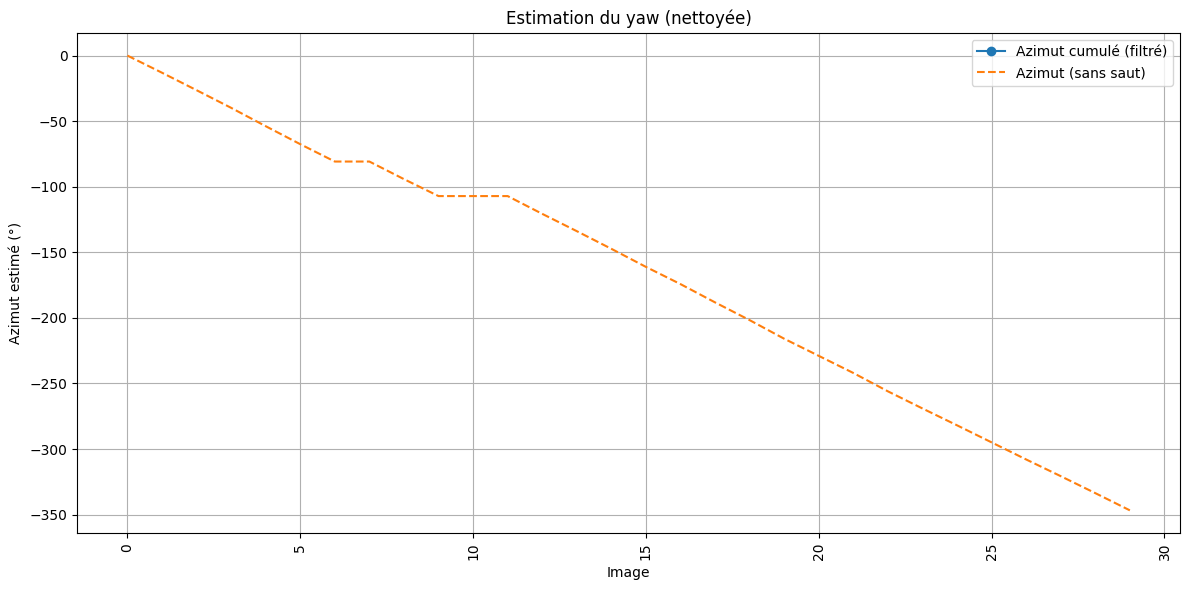

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
import pandas as pd

def estimate_dx_angle(img1, img2, fov_deg=54.2, match_count=100):
    img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    H, W = img1.shape[:2]

    orb = cv2.ORB_create(nfeatures=1000)
    kp1, des1 = orb.detectAndCompute(img1_gray, None)
    kp2, des2 = orb.detectAndCompute(img2_gray, None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)[:match_count]

    margin_x = W * 0.2
    margin_y = H * 0.1

    dx_list = []
    for m in matches:
        x1, y1 = kp1[m.queryIdx].pt
        x2, y2 = kp2[m.trainIdx].pt
        if abs(x1 - W / 2) > margin_x and margin_y < y1 < H - margin_y and margin_y < y2 < H - margin_y:
            dx_list.append(x2 - x1)

    if not dx_list:
        return None

    mean_dx = np.mean(dx_list)
    fov_rad = np.radians(fov_deg)
    angle_rad = 2 * np.arctan((mean_dx * np.tan(fov_rad / 2)) / W)
    return np.degrees(angle_rad)

def process_folder_with_cleaning(folder_path, fov_deg=54.2, max_deviation=5.0):
    image_paths = sorted(glob(os.path.join(folder_path, "*.jpg")))
    if len(image_paths) < 2:
        raise ValueError("Le dossier doit contenir au moins deux images")

    transitions = []
    for i in tqdm(range(len(image_paths) - 1)):
        img1 = cv2.imread(image_paths[i])
        img2 = cv2.imread(image_paths[i + 1])
        angle = estimate_dx_angle(img1, img2, fov_deg=fov_deg)
        transitions.append(angle)

    # Nettoyage : garder seulement les angles proches de la médiane
    median_angle = np.median([a for a in transitions if a is not None])
    cleaned = []
    for i, a in enumerate(transitions):
        if a is None:
            cleaned.append(None)
        elif abs(a - median_angle) <= max_deviation:
            cleaned.append(a)
        else:
            cleaned.append(None)  # Transition ignorée

    # Recalcul des azimuts propres
    azimuts = [None] * (len(cleaned) + 1)

    df = pd.DataFrame({
        "image": [os.path.basename(p) for p in image_paths],
        "azimut_estime": azimuts,
        "delta_angle": [None] + cleaned
    })

    print("\n=== Résumé filtré ===")
    print(df)

    # Affichage
    plt.figure(figsize=(12, 6))
    plt.plot(df["azimut_estime"], marker="o", label="Azimut cumulé (filtré)")
    plt.plot([0] + [sum(a if a is not None else 0 for a in cleaned[:i+1]) for i in range(len(cleaned))],
             linestyle='--', label="Azimut (sans saut)")
    plt.xticks(rotation=90)
    plt.xlabel("Image")
    plt.ylabel("Azimut estimé (°)")
    plt.title("Estimation du yaw (nettoyée)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return df


name = "nemours"
cam_id = "192_168_1_11"


# === Exécution
folder_path = f"/Users/mateo/pyronear/vision/smoke-localization/site_data/{name}/ref_images/{cam_id}"
df_cleaned = process_folder_with_cleaning(folder_path)


In [3]:
import pandas as pd

def compute_session_azimuths(df, ref_image: str, ref_azimuth: float) -> pd.DataFrame:
    """
    Given a DataFrame with columns 'image' and 'delta_angle',
    assign the known azimuth for ref_image, then propagate to all images.
    """
    df = df.copy()
    # pull out the reference delta
    ref_row = df.loc[df['image'] == ref_image]
    if ref_row.empty:
        raise KeyError(f"reference image {ref_image!r} not found")
    ref_delta = ref_row['delta_angle'].iloc[0]
    if pd.isna(ref_delta):
        raise ValueError(f"delta_angle for {ref_image!r} is NaN")

    # compute estimated azimuth for each row
    df['azimut_estime'] = (
        ref_azimuth
        + (df['delta_angle'] - ref_delta)
    ) % 360

    return df




In [4]:
result_df = compute_session_azimuths(
    df_cleaned,
    ref_image="im_12_24.jpg",
    ref_azimuth=309.47,
)
print(result_df)

           image  azimut_estime  delta_angle
0   im_12_00.jpg            NaN          NaN
1   im_12_01.jpg     309.238923   -13.066223
2   im_12_02.jpg     308.987838   -13.317309
3   im_12_03.jpg     308.852699   -13.452447
4   im_12_04.jpg     308.313551   -13.991595
5   im_12_05.jpg     308.583060   -13.722086
6   im_12_06.jpg     309.058769   -13.246377
7   im_12_07.jpg            NaN          NaN
8   im_12_08.jpg     308.898434   -13.406712
9   im_12_09.jpg     309.380466   -12.924680
10  im_12_10.jpg            NaN          NaN
11  im_12_11.jpg            NaN          NaN
12  im_12_12.jpg     308.758189   -13.546957
13  im_12_13.jpg     309.102595   -13.202551
14  im_12_14.jpg     308.848385   -13.456762
15  im_12_15.jpg     308.520904   -13.784242
16  im_12_16.jpg     309.174021   -13.131125
17  im_12_17.jpg     308.368822   -13.936324
18  im_12_18.jpg     308.778783   -13.526363
19  im_12_19.jpg     308.118302   -14.186844
20  im_12_20.jpg     309.252892   -13.052254
21  im_12_

100%|██████████| 29/29 [00:03<00:00,  7.87it/s]



=== Résumé filtré ===
           image  delta_angle  azimut_estime
0   im_12_00.jpg   -13.224464     271.043432
1   im_12_01.jpg   -13.066223     257.977208
2   im_12_02.jpg   -13.317309     244.659900
3   im_12_03.jpg   -13.452447     231.207452
4   im_12_04.jpg   -13.991595     217.215857
5   im_12_05.jpg   -13.722086     203.493771
6   im_12_06.jpg   -13.246377     190.247394
7   im_12_07.jpg   -13.224464     177.022930
8   im_12_08.jpg   -13.406712     163.616217
9   im_12_09.jpg   -12.924680     150.691537
10  im_12_10.jpg   -13.224464     137.467073
11  im_12_11.jpg   -13.224464     124.242609
12  im_12_12.jpg   -13.546957     110.695652
13  im_12_13.jpg   -13.202551      97.493101
14  im_12_14.jpg   -13.456762      84.036339
15  im_12_15.jpg   -13.784242      70.252097
16  im_12_16.jpg   -13.131125      57.120972
17  im_12_17.jpg   -13.936324      43.184649
18  im_12_18.jpg   -13.526363      29.658285
19  im_12_19.jpg   -14.186844      15.471441
20  im_12_20.jpg   -13.052254   

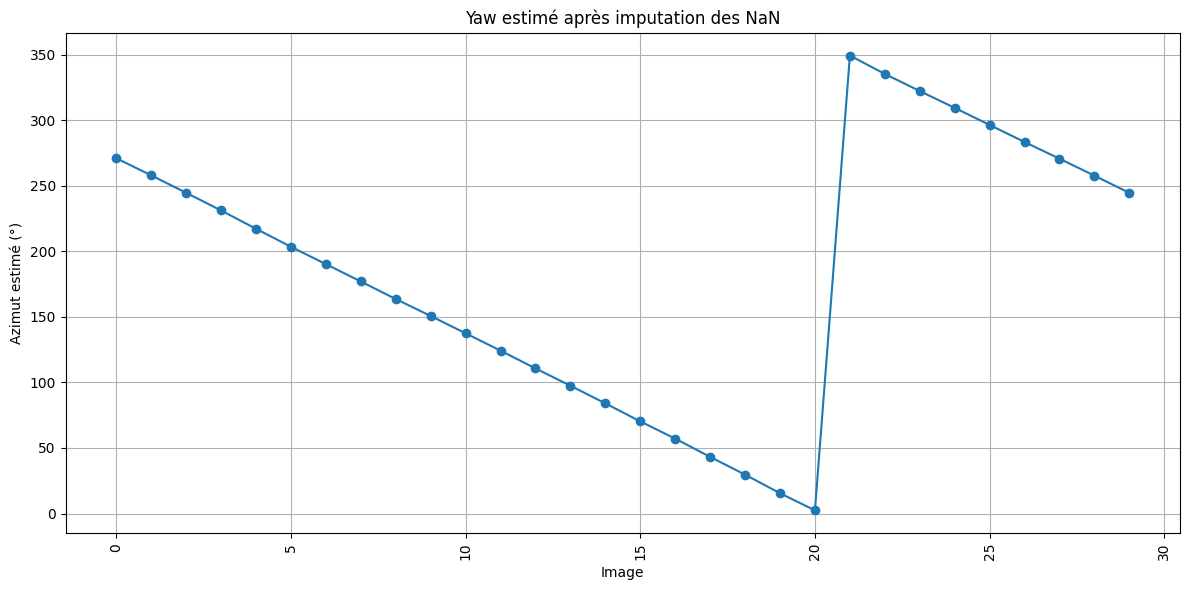

In [10]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
import pandas as pd

def estimate_dx_angle(img1, img2, fov_deg=54.2, match_count=100):
    img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    H, W = img1.shape[:2]

    orb = cv2.ORB_create(nfeatures=1000)
    kp1, des1 = orb.detectAndCompute(img1_gray, None)
    kp2, des2 = orb.detectAndCompute(img2_gray, None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)[:match_count]

    margin_x = W * 0.2
    margin_y = H * 0.1

    dx_list = []
    for m in matches:
        x1, y1 = kp1[m.queryIdx].pt
        x2, y2 = kp2[m.trainIdx].pt
        if abs(x1 - W/2) > margin_x and margin_y < y1 < H - margin_y and margin_y < y2 < H - margin_y:
            dx_list.append(x2 - x1)

    if not dx_list:
        return None

    mean_dx = np.mean(dx_list)
    fov_rad = np.radians(fov_deg)
    angle_rad = 2 * np.arctan((mean_dx * np.tan(fov_rad/2)) / W)
    return np.degrees(angle_rad)

def process_folder_with_cleaning(folder_path,
                                 ref_image=None,
                                 ref_azimuth=None,
                                 fov_deg=54.2,
                                 max_deviation=5.0):
    image_paths = sorted(glob(os.path.join(folder_path, "*.jpg")))
    if len(image_paths) < 2:
        raise ValueError("Le dossier doit contenir au moins deux images")

    transitions = []
    for i in tqdm(range(len(image_paths) - 1)):
        img1 = cv2.imread(image_paths[i])
        img2 = cv2.imread(image_paths[i + 1])
        transitions.append(estimate_dx_angle(img1, img2, fov_deg=fov_deg))

    median_trans = np.median([a for a in transitions if a is not None])
    cleaned = [
        a if a is not None and abs(a - median_trans) <= max_deviation
        else None
        for a in transitions
    ]

    df = pd.DataFrame({
        "image": [os.path.basename(p) for p in image_paths],
        "delta_angle": [None] + cleaned
    })

    if ref_image and ref_azimuth is not None:
        # imputer la mediane sur tous les NaN de delta_angle
        med_delta = df["delta_angle"].dropna().median()
        df["delta_angle"] = df["delta_angle"].fillna(med_delta)

        # cumul des deltas
        df["cum_delta"] = df["delta_angle"].cumsum()

        # position de la reference
        if ref_image not in df["image"].values:
            raise KeyError(f"Image de reference {ref_image!r} introuvable")
        ref_idx = df.index[df["image"] == ref_image][0]
        ref_cum = df.loc[ref_idx, "cum_delta"]

        # calcul de chaque azimut_estime
        df["azimut_estime"] = (
            ref_azimuth + (df["cum_delta"] - ref_cum)
        ) % 360

        df.drop(columns=["cum_delta"], inplace=True)
    else:
        df["azimut_estime"] = None

    print("\n=== Résumé filtré ===")
    print(df)

    # affichage si besoin
    plt.figure(figsize=(12, 6))
    plt.plot(df["azimut_estime"], marker="o", label="Azimut cumulé")
    plt.xticks(rotation=90)
    plt.xlabel("Image")
    plt.ylabel("Azimut estimé (°)")
    plt.title("Yaw estimé après imputation des NaN")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return df

# exemple d’appel
folder_path = "/Users/mateo/pyronear/vision/smoke-localization/nemours_12_session_20250523_095927"
df_cleaned = process_folder_with_cleaning(
    folder_path,
    ref_image="im_12_24.jpg",
    ref_azimuth=309.47
)


df_cleaned.to_csv("nemours_12_session_20250523_095927.csv")

In [8]:
df_cleaned

,image,delta_angle,azimut_estime
0,im_12_00.jpg,-13.224464,271.043432
1,im_12_01.jpg,-13.066223,257.977208
2,im_12_02.jpg,-13.317309,244.659900
3,im_12_03.jpg,-13.452447,231.207452
4,im_12_04.jpg,-13.991595,217.215857
5,im_12_05.jpg,-13.722086,203.493771
6,im_12_06.jpg,-13.246377,190.247394
7,im_12_07.jpg,-13.224464,177.022930
8,im_12_08.jpg,-13.406712,163.616217
9,im_12_09.jpg,-12.924680,150.691537


100%|██████████| 35/35 [00:04<00:00,  8.16it/s]


=== Résumé filtré ===
           image  delta_angle  azimut_estime
0   im_11_00.jpg   -13.307146     234.758196
1   im_11_01.jpg   -13.016272     221.741924
2   im_11_02.jpg   -12.457470     209.284454
3   im_11_03.jpg   -13.000057     196.284397
4   im_11_04.jpg   -12.988623     183.295774
5   im_11_05.jpg   -13.682475     169.613299
6   im_11_06.jpg   -14.044940     155.568360
7   im_11_07.jpg   -13.012440     142.555920
8   im_11_08.jpg   -13.730453     128.825467
9   im_11_09.jpg   -13.858558     114.966909
10  im_11_10.jpg   -13.721643     101.245266
11  im_11_11.jpg   -13.307146      87.938120
12  im_11_12.jpg   -13.332679      74.605441
13  im_11_13.jpg   -14.477380      60.128061
14  im_11_14.jpg   -13.307146      46.820915
15  im_11_15.jpg   -13.267158      33.553757
16  im_11_16.jpg   -13.213757      20.340000
17  im_11_17.jpg   -13.307146       7.032854
18  im_11_18.jpg   -13.505648     353.527206
19  im_11_19.jpg   -14.245020     339.282187
20  im_11_20.jpg   -14.412244   

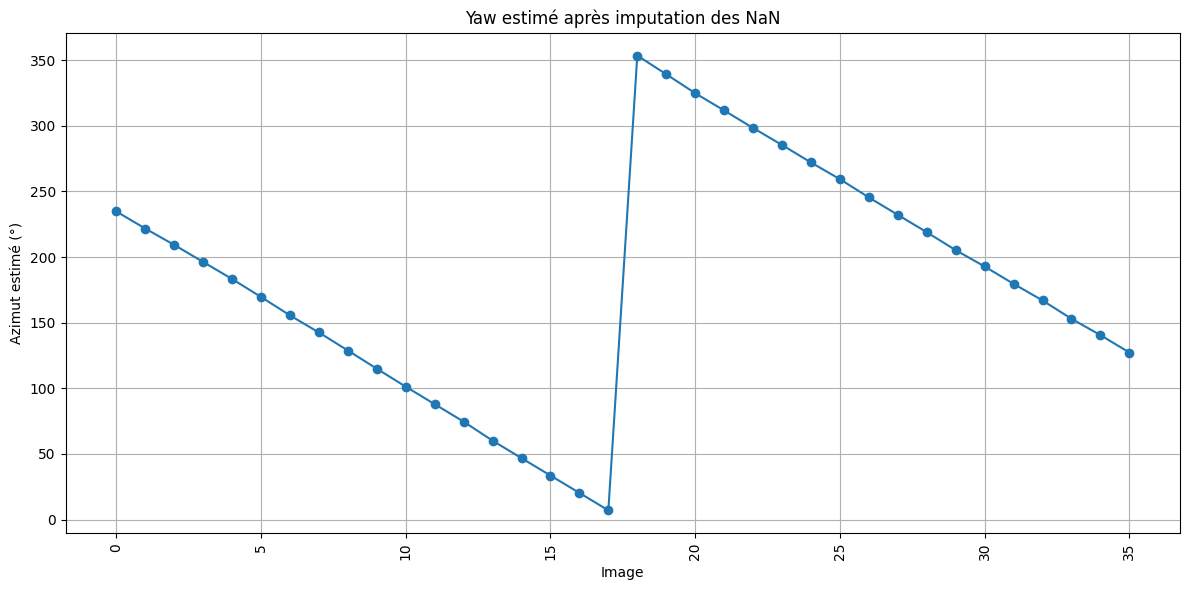

In [11]:
# exemple d’appel
folder_path = "/Users/mateo/pyronear/vision/smoke-localization/nemours_11_session_20250523_095643"
df_cleaned = process_folder_with_cleaning(
    folder_path,
    ref_image="im_11_16.jpg",
    ref_azimuth=20.34
)


df_cleaned.to_csv("nemours_11_session_20250523_095643.csv")

In [12]:
import os
import cv2
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm

def match_and_assign_azimuth(target_folder: str,
                             ref_folder: str,
                             azimuth_map: dict,
                             orb_features: int = 1000,
                             match_thresh: int = 50) -> pd.DataFrame:
    """
    For each image in target_folder, find the reference image in ref_folder
    with the most ORB matches, then assign its azimuth via azimuth_map.
    
    Parameters
    ----------
    target_folder : path to the folder of new images
    ref_folder    : path to the reference session folder
    azimuth_map   : dict mapping reference image basename to azimut_estime
    orb_features  : number of ORB features to detect
    match_thresh  : maximum Hamming distance for a match to count
    
    Returns
    -------
    DataFrame with columns image, best_match, match_count, estimated_azimuth
    """
    # collect file lists
    target_paths = sorted(glob(os.path.join(target_folder, "*.jpg")))
    ref_paths    = sorted(glob(os.path.join(ref_folder,    "*.jpg")))

    # init ORB detector and BF matcher
    orb = cv2.ORB_create(nfeatures=orb_features)
    bf  = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

    # precompute keypoints and descriptors for reference images
    ref_data = {}
    for path in tqdm(ref_paths, desc="loading reference images"):
        img = cv2.imread(path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        kp, des = orb.detectAndCompute(gray, None)
        ref_data[path] = (kp, des)

    results = []
    # iterate over each target image
    for tpath in tqdm(target_paths, desc="matching target images"):
        img_t = cv2.imread(tpath)
        gray_t = cv2.cvtColor(img_t, cv2.COLOR_BGR2GRAY)
        kp_t, des_t = orb.detectAndCompute(gray_t, None)

        best_count = -1
        best_ref   = None

        if des_t is None:
            # no features found in target
            match_count = 0
        else:
            # compare against every reference
            for rpath, (kp_r, des_r) in ref_data.items():
                if des_r is None:
                    continue
                matches = bf.match(des_t, des_r)
                # count only matches below threshold
                count = sum(1 for m in matches if m.distance <= match_thresh)
                if count > best_count:
                    best_count = count
                    best_ref   = rpath
            match_count = best_count if best_count >= 0 else 0

        # deduce azimuth from the best matched reference
        if best_ref is None:
            est_az = None
            best_name = None
        else:
            best_name = os.path.basename(best_ref)
            est_az = azimuth_map.get(best_name)

        results.append({
            "image": os.path.basename(tpath),
            "best_match": best_name,
            "match_count": match_count,
            "estimated_azimuth": est_az
        })

    return pd.DataFrame(results)




In [16]:
# after you compute df_cleaned
df_cleaned = pd.read_csv("nemours_11_session_20250523_095643.csv")

# build azimuth_map from that same dataframe
azimuth_map = dict(zip(df_cleaned["image"], df_cleaned["azimut_estime"]))

# then run the matching as before
target_folder = "/Users/mateo/pyronear/test/forcus77/captured_images_roche/11"
ref_folder    = "/Users/mateo/pyronear/vision/smoke-localization/nemours_11_session_20250523_095643"

df_matches = match_and_assign_azimuth(
    target_folder,
    ref_folder,
    azimuth_map,
    orb_features=1000,
    match_thresh=50
)

df_matches.to_csv("capture_11_with_estimated_azimuth.csv", index=False)
print(df_matches)


matching target images: 100%|██████████| 7/7 [00:00<00:00, 18.03it/s]

                   image    best_match  match_count  estimated_azimuth
0  192_168_1_11_im_1.jpg  im_11_13.jpg           35          60.128061
1  192_168_1_11_im_2.jpg  im_11_18.jpg           44         353.527206
2  192_168_1_11_im_3.jpg  im_11_22.jpg           38         298.371106
3  192_168_1_11_im_4.jpg  im_11_07.jpg           16         142.555920
4  192_168_1_11_im_5.jpg  im_11_13.jpg           35          60.128061
5  192_168_1_11_im_6.jpg  im_11_13.jpg           34          60.128061
6  192_168_1_11_im_7.jpg  im_11_07.jpg           60         142.555920


In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def debug_match_and_compute_dangle(path1,
                                   path2,
                                   fov_deg=54.2,
                                   nfeatures=1000,
                                   top_matches=50,
                                   distance_thresh=30):
    # load
    img1 = cv2.imread(path1)
    img2 = cv2.imread(path2)

    # resize img2 to img1’s width,height
    h1, w1 = img1.shape[:2]
    print(h1,w1)
    img2 = cv2.resize(img2, (w1, h1))

    # convert to gray
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    H, W = gray1.shape

    # detect ORB
    orb = cv2.ORB_create(nfeatures=nfeatures)
    kp1, des1 = orb.detectAndCompute(gray1, None)
    kp2, des2 = orb.detectAndCompute(gray2, None)

    # match
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    good = [m for m in matches if m.distance <= distance_thresh]
    good = sorted(good, key=lambda m: m.distance)[:top_matches]

    # draw
    matched_img = cv2.drawMatches(
        img1, kp1,
        img2, kp2,
        good, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    plt.figure(figsize=(12,6))
    plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    # compute mean dx and delta angle
    dxs = [(kp2[m.trainIdx].pt[0] - kp1[m.queryIdx].pt[0])
           for m in good]
    if not dxs:
        print("No good matches")
        return None

    mean_dx = np.mean(dxs)
    fov_rad = np.radians(fov_deg)
    angle_rad = 2 * np.arctan((mean_dx * np.tan(fov_rad/2)) / W)
    delta_angle = np.degrees(angle_rad)

    print(f"mean dx in pixels : {mean_dx:.2f}")
    print(f"delta angle in degrees : {delta_angle:.2f}")

    return delta_angle





720 1280


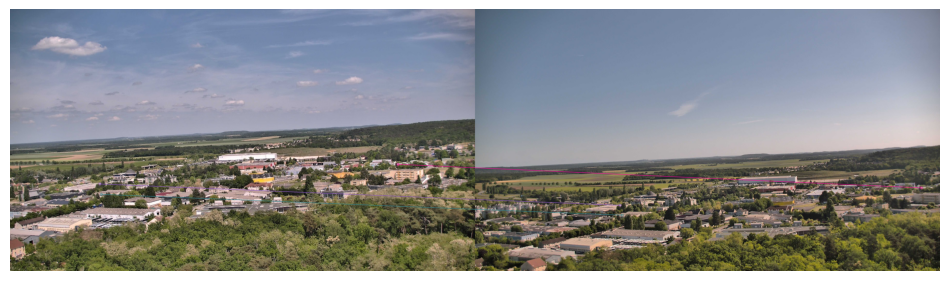

mean dx in pixels : 155.81
delta angle in degrees : 7.13


In [34]:
img_a = os.path.join(target_folder, "192_168_1_11_im_2.jpg")
img_b = os.path.join(ref_folder, "im_11_18.jpg")
dangle = debug_match_and_compute_dangle(img_a, img_b)